# WAVEWATCH III Idealized Run — 2-D Propagation (real model output)

**Runnable companion to [`ww3-model-guide.md`](../ww3-model-guide.md) §13a
(Idealized test case).**

WW3's regression-test suite includes self-contained **propagation** cases that
need no external data: a wave packet is advected across a flat domain with the
source terms switched off (`ST0`), so the result is pure numerical propagation.
This notebook plots **real output** from the `ww3_tp2.2` test, built with CMake
(gfortran / conda toolchain).

```bash
# CMake build (point at the repo root; switch selects the physics):
cmake -S . -B build -DSWITCH=regtests/ww3_tp2.2/input/switch -DCMAKE_INSTALL_PREFIX=install
cmake --build build -j && cmake --install build

# run the chain in a work dir (LC_ALL=C for the locale):
LC_ALL=C ww3_grid && ww3_strt && ww3_shel && ww3_ounf   # → ww3.YYYYMM.nc
```

> Switch used: `NOGRB SHRD PR3 UQ ... ST0 ...` — third-order (UQ) propagation,
> serial, no source terms. Committed: a compact extract of the gridded `hs`
> field (5 frames) plus mean period/direction.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

ds = xr.open_dataset(sampledata.ww3_propagation_path())
lon, lat = ds["longitude"].values, ds["latitude"].values
nt = ds.sizes["time"]
plt.rcParams["figure.dpi"] = 110
print(ds.attrs["title"])
print(f"grid {ds.sizes['longitude']}x{ds.sizes['latitude']}, {nt} frames, "
      f"Hs max {float(np.nanmax(ds['hs'])):.2f} m")

Compact real WW3 ww3_tp2.2 propagation test output
grid 193x93, 5 frames, Hs max 2.69 m


## 1 · The wave packet propagating

Each frame shows significant wave height `Hs`. The packet translates across the
domain at the group velocity, holding its shape — a clean test that the
advection scheme (here third-order UQ) is accurate and low-diffusion.

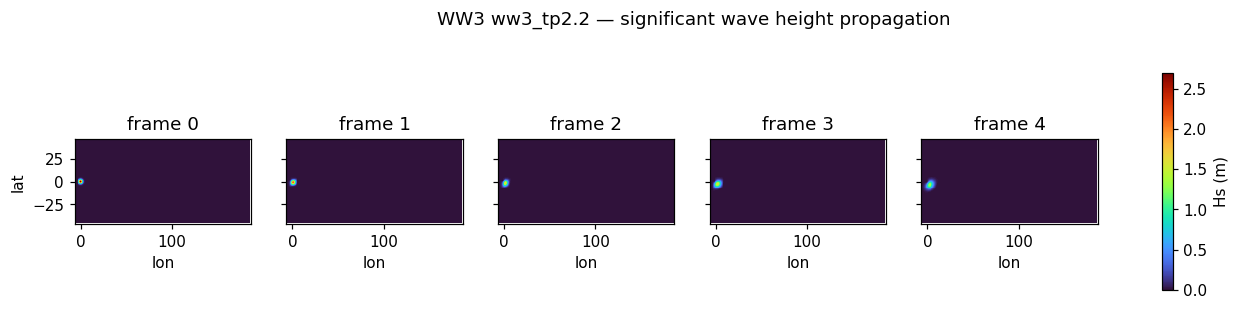

In [2]:
hs = ds["hs"].values
vmax = np.nanmax(hs)
fig, axes = plt.subplots(1, nt, figsize=(3.0 * nt, 3.2), sharey=True)
for k, ax in enumerate(axes):
    pcm = ax.pcolormesh(lon, lat, hs[k], cmap="turbo", vmin=0, vmax=vmax, shading="auto")
    ax.set(title=f"frame {k}", xlabel="lon")
    ax.set_aspect("equal")
axes[0].set_ylabel("lat")
fig.colorbar(pcm, ax=axes, label="Hs (m)", shrink=0.8)
fig.suptitle("WW3 ww3_tp2.2 — significant wave height propagation"); plt.show()

## 2 · Conservation & shape along the transect

A centerline slice across frames shows the peak advecting with little amplitude loss — the signature of an accurate propagation scheme.

peak Hs per frame: [nan, nan, nan, nan, nan]


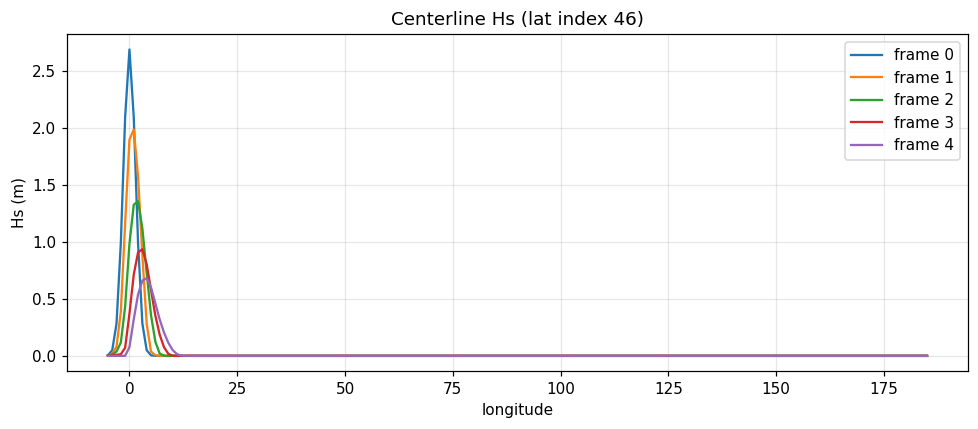

In [3]:
jmid = hs.shape[1] // 2
fig, ax = plt.subplots(figsize=(9, 4))
for k in range(nt):
    ax.plot(lon, hs[k, jmid], label=f"frame {k}")
ax.set(xlabel="longitude", ylabel="Hs (m)", title=f"Centerline Hs (lat index {jmid})")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
print("peak Hs per frame:", [round(float(hs[k, jmid].max()), 2) for k in range(nt)])

## 3 · Mean period and direction (final frame)

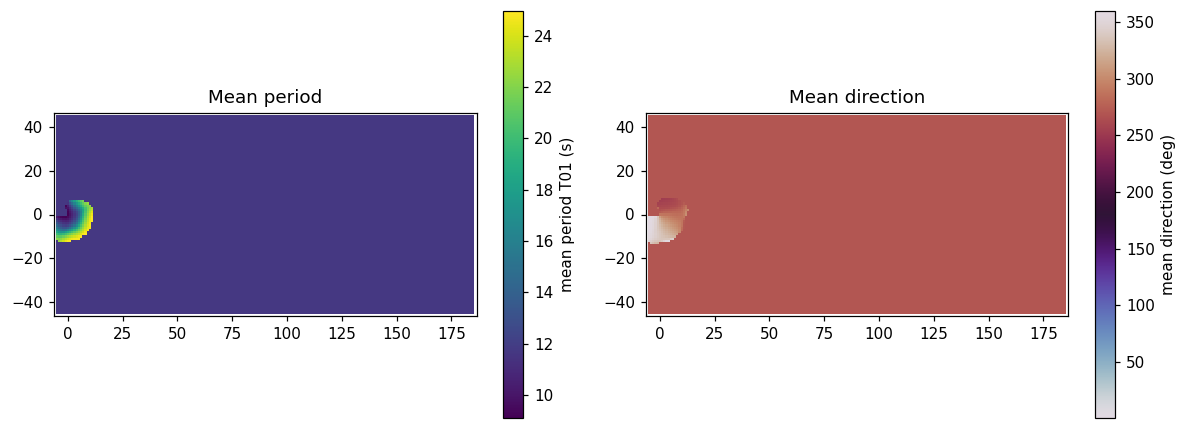

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
p1 = a1.pcolormesh(lon, lat, ds["t01"].values, cmap="viridis", shading="auto")
plt.colorbar(p1, ax=a1, label="mean period T01 (s)"); a1.set_title("Mean period"); a1.set_aspect("equal")
p2 = a2.pcolormesh(lon, lat, ds["dir"].values, cmap="twilight", shading="auto")
plt.colorbar(p2, ax=a2, label="mean direction (deg)"); a2.set_title("Mean direction"); a2.set_aspect("equal")
plt.tight_layout()

---
### Reproduce / extend
- Build with CMake from the WW3 repo root: `cmake -S . -B build -DSWITCH=<switch>`.
  Each regtest's `input/switch` selects the physics.
- The full regression suite runs via `regtests/bin/run_test`. For a regional
  hindcast with source terms (`ST6`) and real winds, see the WW3 guide §13b.
- Verify modelled `hs` against buoys/altimetry with
  [`../../observations/notebooks/ocean_obs_access.ipynb`](../../observations/notebooks/ocean_obs_access.ipynb)
  and the scatter index. For spectra, see
  [`swan_idealized_fetch.ipynb`](swan_idealized_fetch.ipynb) and
  [`wave_spectra.ipynb`](wave_spectra.ipynb).